# Phase 4: Customer Analytics (RFM Analysis)

## Objective

Customer Analytics helps identify valuable customers based on their purchasing behavior.

### RFM stands for:

- **Recency (R):** How recently a customer made a purchase.
- **Frequency (F):** How often a customer places orders.
- **Monetary (M):** How much money a customer spends.

Businesses use RFM analysis to identify:

- Loyal Customers
- High-Value Customers
- At-Risk Customers
- New Customers

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("../data/cleaned_superstore.csv")

# Convert Order Date into datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"])

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


## Calculate Recency

Recency is calculated by finding the number of days since the customer's last purchase.

In [2]:
# Find the latest order date
snapshot_date = df["Order Date"].max()

snapshot_date

Timestamp('2026-12-30 00:00:00')

In [3]:
# Calculate RFM metrics

rfm = df.groupby("Customer ID").agg({

    "Order Date": lambda x: (snapshot_date - x.max()).days,

    "Order ID": "nunique",

    "Sales": "sum"

})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,184,5,5563.560
AA-10375,19,9,1056.390
AA-10480,259,4,1790.512
AA-10645,55,6,5086.935
AB-10015,415,3,886.156


## RFM Summary Statistics

In [4]:
rfm.describe()

,Recency,Frequency,Monetary
count,804.000000,804.000000,804.000000
mean,146.016169,6.364428,2893.699446
std,185.551511,2.660121,2653.778471
min,0.000000,1.000000,4.833000
25%,29.000000,5.000000,1084.538000
50%,75.000000,6.000000,2243.392000
75%,180.750000,8.000000,3790.812100
max,1165.000000,17.000000,25043.050000


## Top 10 Highest Spending Customers

In [5]:
top_customers = rfm.sort_values(
    by="Monetary",
    ascending=False
).head(10)

top_customers

,Recency,Frequency,Monetary
Customer ID,,,
SM-20320,79,5,25043.050
TC-20980,399,5,19052.218
RB-19360,96,6,15117.339
TA-21385,69,4,14595.620
AB-10105,41,10,14473.571
KL-16645,47,12,14175.229
SC-20095,349,9,14142.334
HL-15040,43,6,12873.298
SE-20110,9,11,12209.438


## Visualize Top Spending Customers

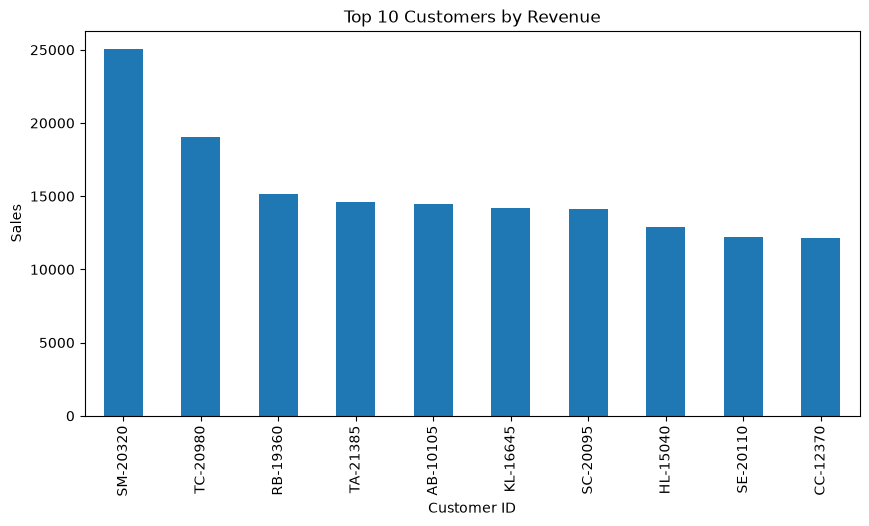

In [6]:
top_customers["Monetary"].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Customers by Revenue")

plt.xlabel("Customer ID")

plt.ylabel("Sales")

plt.show()

## Most Frequent Customers

In [7]:
top_frequency = rfm.sort_values(
    by="Frequency",
    ascending=False
).head(10)

top_frequency

,Recency,Frequency,Monetary
Customer ID,,,
EP-13915,12,17,5478.0608
EH-14125,72,14,3143.4830
SM-20950,25,14,5695.7900
BP-11095,17,14,3350.8740
ZC-21910,54,13,8025.7070
XP-21865,43,13,2503.1560
PG-18820,36,13,3086.9070
EA-14035,152,13,2846.7050
NS-18640,174,13,2964.8230


## Visualize Most Frequent Customers

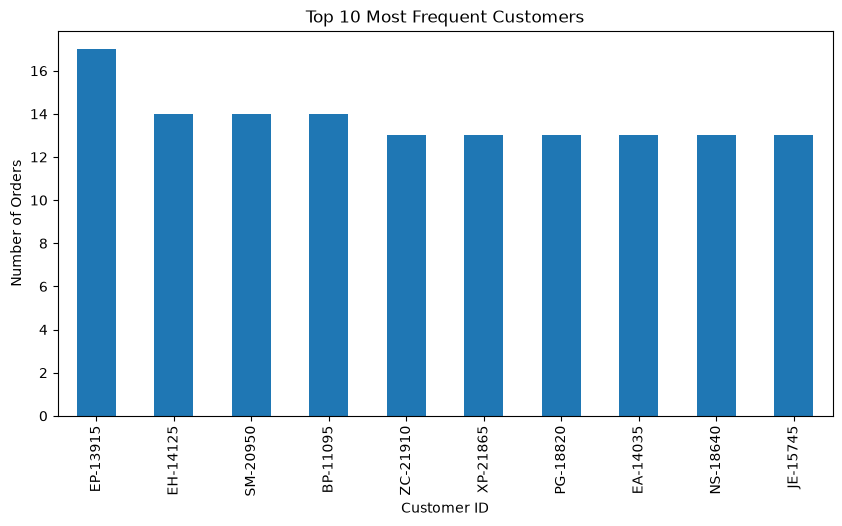

In [8]:
top_frequency["Frequency"].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Most Frequent Customers")

plt.xlabel("Customer ID")

plt.ylabel("Number of Orders")

plt.show()

## Customers with the Lowest Recency

Lower recency means the customer purchased more recently.

In [9]:
recent_customers = rfm.sort_values(
    by="Recency"
).head(10)

recent_customers

,Recency,Frequency,Monetary
Customer ID,,,
CC-12430,0,12,4606.952
HO-15230,0,2,6.048
JM-15580,0,5,303.948
PO-18865,0,7,2493.214
EB-13975,0,4,1643.255
JP-11135,1,5,515.200
BG-18435,1,5,609.880
MC-17845,1,7,3805.714
BP-11185,1,9,3675.861


## Visualize Recently Active Customers

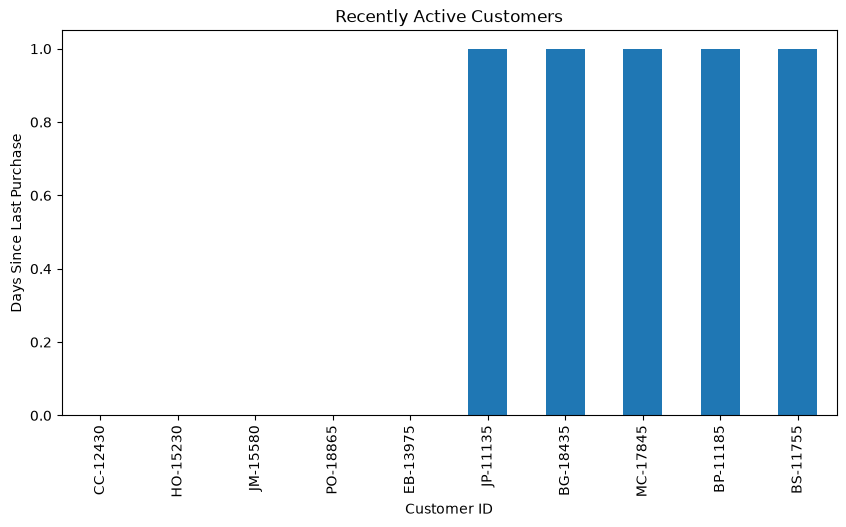

In [10]:
recent_customers["Recency"].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Recently Active Customers")

plt.xlabel("Customer ID")

plt.ylabel("Days Since Last Purchase")

plt.show()

# Business Insights

### Key Findings

- High-value customers contribute significantly to total revenue.
- Frequent customers place multiple orders and should be retained through loyalty programs.
- Recently active customers are more likely to respond to promotional campaigns.
- RFM analysis helps businesses prioritize marketing efforts and improve customer retention.

In [3]:
import pandas as pd

df = pd.read_csv(r"P:\DA\ECommerce_Analytics\data\cleaned_superstore.csv")

In [4]:
df["Customer ID"].nunique()

804